<a href="https://www.kaggle.com/code/lalit7881/daily-news-based-stock-market-prediction-eda-100?scriptVersionId=316180343" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sumeakash/daily-news-for-stock-market-prediction/stock_news_2016 to 2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sumeakash/daily-news-for-stock-market-prediction/stock_news_2016 to 2026.csv")

In [3]:
df.head()

,date,title,description,url,source_file,categories,matched_keywords,relevance_score,has_negation,impact_tier
0,2016-01-01,Lending to foreign step-down arms of Indian fi...,RBI slaps 2% additional provision for such loans,URL_NOT_AVAILABLE,IndianFinancialNews.csv,sector_banking_finance,rbi,2,False,LOW
1,2016-01-02,IDBI Bank to raise Rs 900 cr through Basel-III...,Many banks have been raising money through tie...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,sector_banking_finance,basel,2,False,LOW
2,2016-01-02,Forex reserves up $943 mn,India's foreign exchange reserves rose $943 mi...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,macro_government,forex reserve,3,False,MEDIUM
3,2016-01-02,SBI: Lending rate cut unlikely till end-Mar,Country's largest lender SBI today ruled out f...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,stock_specific,sbi,2,True,LOW
4,2016-01-03,"ASK Group to invest Rs 1,500 cr in real estate...",ASK Group plans to step up its equity investme...,URL_NOT_AVAILABLE,IndianFinancialNews.csv,sector_cement_infra,real estate,1,False,LOW


In [4]:
df.tail()

,date,title,description,url,source_file,categories,matched_keywords,relevance_score,has_negation,impact_tier
139914,2026-04-15,ETMarkets Smart Talk | FY27 volatility a phase...,FY27 begins with market volatility due to geop...,https://economictimes.indiatimes.com/markets/e...,news_gap_2025_06_12_to_2026_04_15.csv,macro_government|geopolitical,capex|geopolitical tension,6,False,HIGH
139915,2026-04-15,Half-billion dollar BBL sell-off stalls as sta...,Governing bodies in NSW and Queensland urged p...,https://www.theguardian.com/p/x4zfqj,news_gap_2025_06_12_to_2026_04_15.csv,macro_government,dollar,3,False,MEDIUM
139916,2026-04-15,How the US-Israel war on Iran is affecting Afr...,"For some, the impact is already being felt but...",https://www.theguardian.com/p/x4zbmn,news_gap_2025_06_12_to_2026_04_15.csv,geopolitical,war,3,False,MEDIUM
139917,2026-04-15,LG Electronics shares in focus as lock-in expi...,LG Electronics India shares are in focus as a ...,https://economictimes.indiatimes.com/markets/s...,news_gap_2025_06_12_to_2026_04_15.csv,macro_government,ipo,3,False,MEDIUM
139918,2026-04-15,Stock Market Opening Bell: Sensex Surges 1.48%...,The Indian benchmark stock market indices BSE ...,https://www.republicworld.com/business/stock-m...,news_gap_2025_06_12_to_2026_04_15.csv,macro_government,nifty 50|sensex,3,False,MEDIUM


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139919 entries, 0 to 139918
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   date              139919 non-null  object
 1   title             139919 non-null  object
 2   description       139919 non-null  object
 3   url               139919 non-null  object
 4   source_file       139919 non-null  object
 5   categories        139919 non-null  object
 6   matched_keywords  139919 non-null  object
 7   relevance_score   139919 non-null  int64 
 8   has_negation      139919 non-null  bool  
 9   impact_tier       139919 non-null  object
dtypes: bool(1), int64(1), object(8)
memory usage: 9.7+ MB


In [6]:
df.describe()

,relevance_score
count,139919.00000
mean,2.78822
std,1.11695
min,1.00000
25%,2.00000
50%,3.00000
75%,3.00000
max,11.00000


In [7]:
df.isnull().sum()

date                0
title               0
description         0
url                 0
source_file         0
categories          0
matched_keywords    0
relevance_score     0
has_negation        0
impact_tier         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['date', 'title', 'description', 'url', 'source_file', 'categories',
       'matched_keywords', 'relevance_score', 'has_negation', 'impact_tier'],
      dtype='object')

In [10]:
df.dtypes

date                object
title               object
description         object
url                 object
source_file         object
categories          object
matched_keywords    object
relevance_score      int64
has_negation          bool
impact_tier         object
dtype: object

In [11]:
df.shape

(139919, 10)

In [12]:
df.nunique()

date                  3182
title               139906
description         139867
url                 134565
source_file              7
categories             366
matched_keywords     10061
relevance_score         11
has_negation             2
impact_tier              3
dtype: int64

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139919 entries, 0 to 139918
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              139919 non-null  datetime64[ns]
 1   title             139919 non-null  object        
 2   description       139919 non-null  object        
 3   url               139919 non-null  object        
 4   source_file       139919 non-null  object        
 5   categories        139919 non-null  object        
 6   matched_keywords  139919 non-null  object        
 7   relevance_score   139919 non-null  int64         
 8   has_negation      139919 non-null  bool          
 9   impact_tier       139919 non-null  object        
dtypes: bool(1), datetime64[ns](1), int64(1), object(7)
memory usage: 9.7+ MB
None
        date                                              title  \
0 2016-01-01  Lending to foreign step-down arms of Indian fi...   
1 2016-01-02

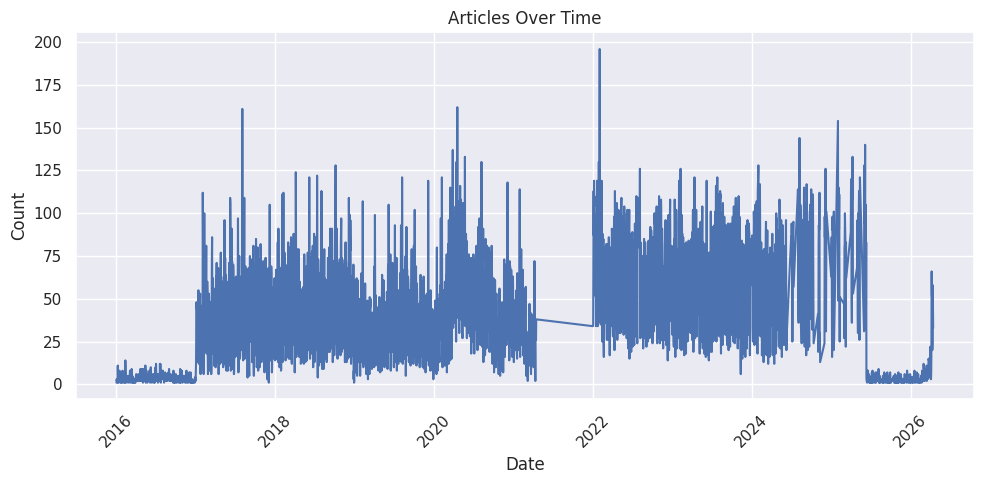

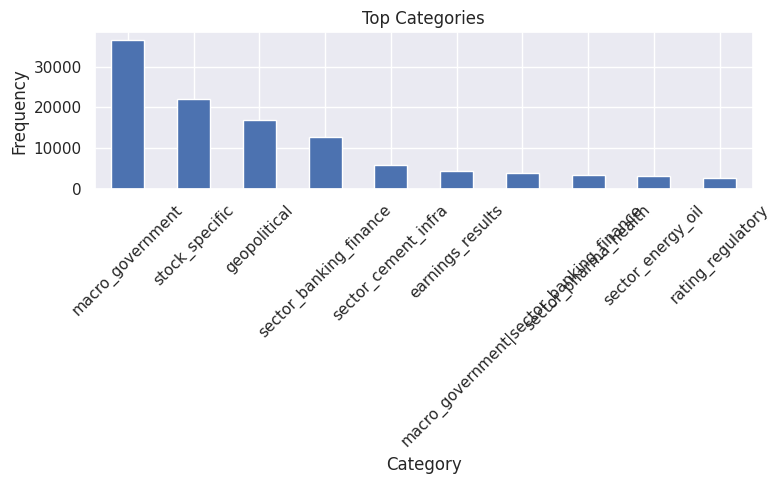

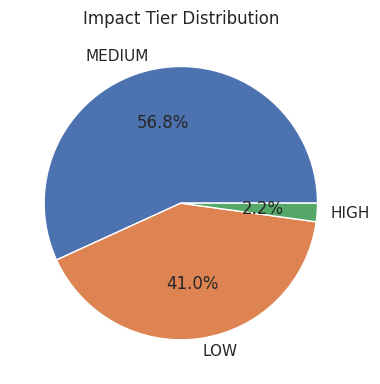

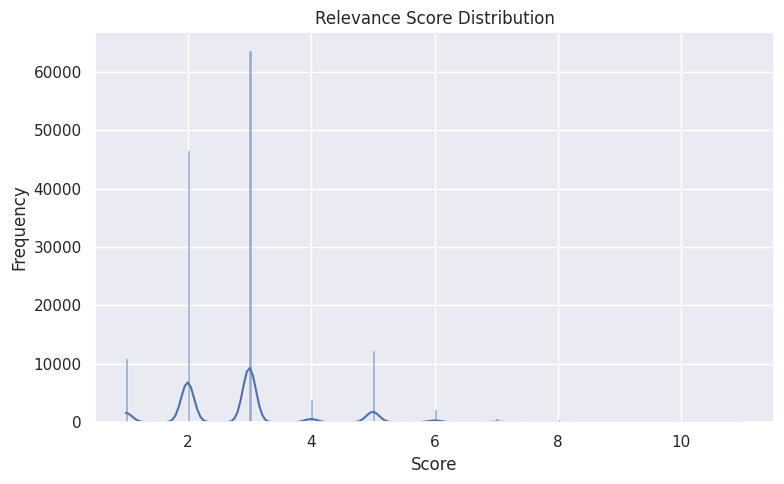

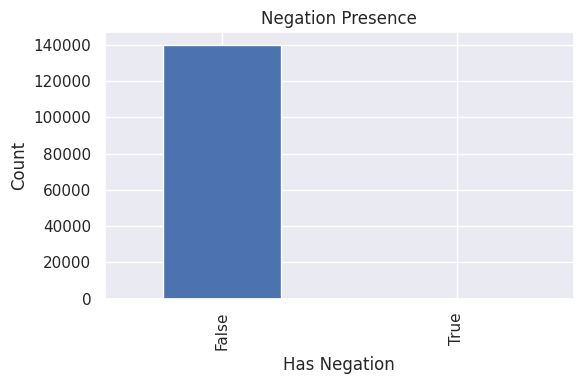

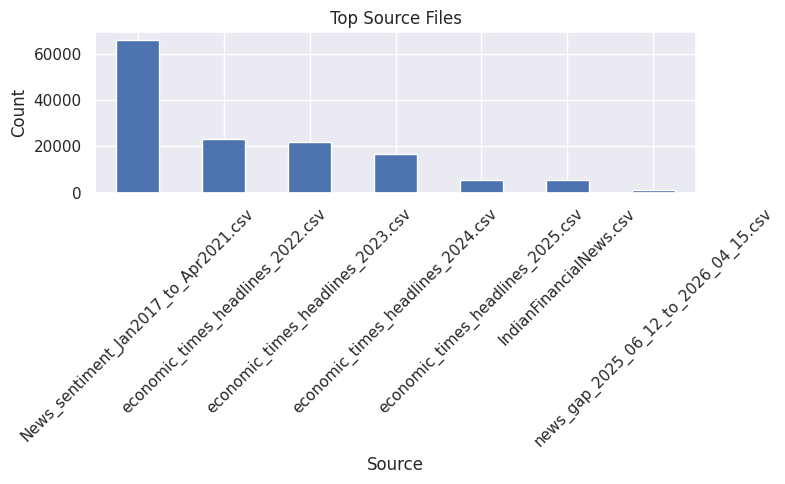

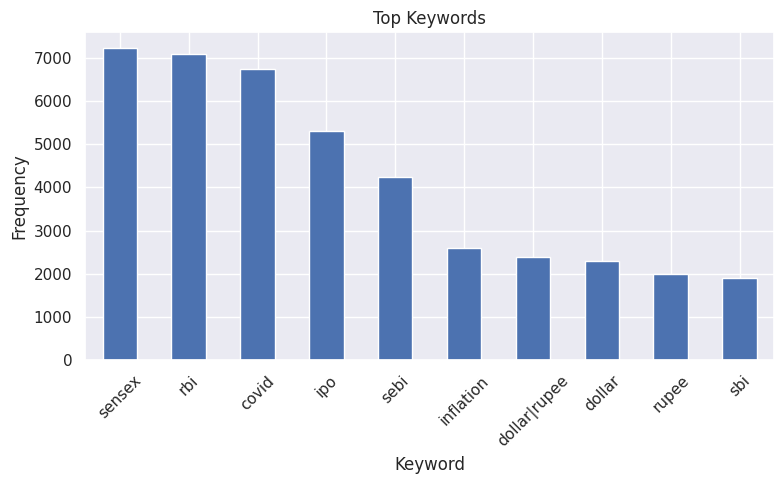

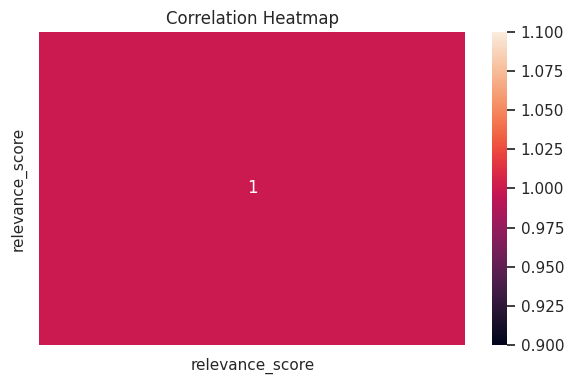

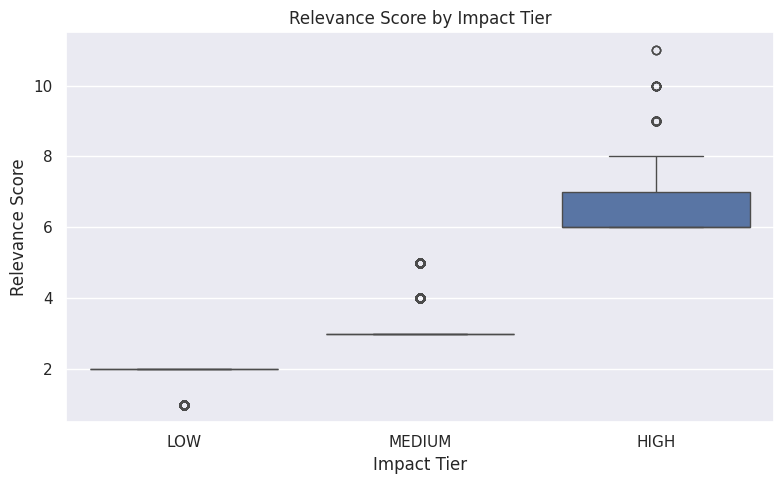

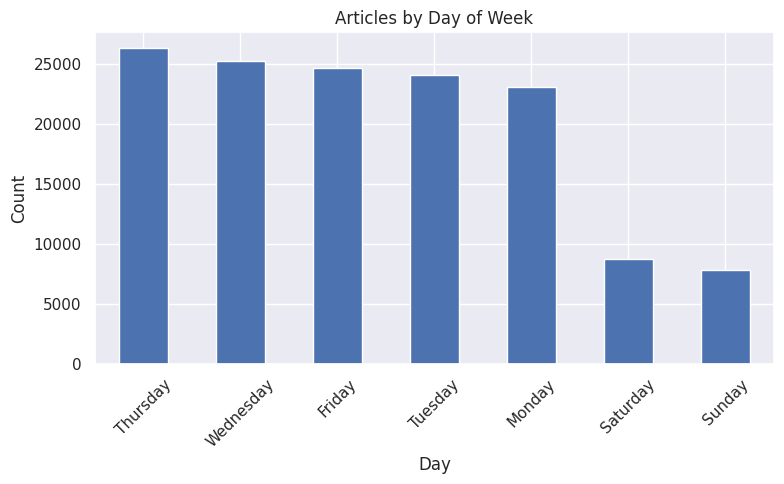

In [13]:
# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# =========================
# BASIC INFO
# =========================
print(df.info())
print(df.head())

# =========================
# SET STYLE
# =========================
plt.style.use('default')   # keep default (no forced theme)
sns.set()

# =========================
# 1. COUNT OF ARTICLES OVER TIME
# =========================
plt.figure(figsize=(10,5))
df.groupby(df['date'].dt.date).size().plot(kind='line')
plt.title("Articles Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 2. CATEGORY DISTRIBUTION
# =========================
plt.figure(figsize=(8,5))
df['categories'].value_counts().head(10).plot(kind='bar')
plt.title("Top Categories")
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 3. IMPACT TIER DISTRIBUTION
# =========================
plt.figure(figsize=(6,4))
df['impact_tier'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Impact Tier Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

# =========================
# 4. RELEVANCE SCORE DISTRIBUTION
# =========================
plt.figure(figsize=(8,5))
sns.histplot(df['relevance_score'], kde=True)
plt.title("Relevance Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# =========================
# 5. NEGATION ANALYSIS
# =========================
plt.figure(figsize=(6,4))
df['has_negation'].value_counts().plot(kind='bar')
plt.title("Negation Presence")
plt.xlabel("Has Negation")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# =========================
# 6. SOURCE FILE DISTRIBUTION
# =========================
plt.figure(figsize=(8,5))
df['source_file'].value_counts().head(10).plot(kind='bar')
plt.title("Top Source Files")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 7. KEYWORDS ANALYSIS
# =========================
# Split keywords if comma separated
keywords_series = df['matched_keywords'].dropna().str.split(',')

# Flatten list
all_keywords = keywords_series.explode()

plt.figure(figsize=(8,5))
all_keywords.value_counts().head(10).plot(kind='bar')
plt.title("Top Keywords")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 8. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(6,4))
numeric_cols = ['relevance_score']
sns.heatmap(df[numeric_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# =========================
# 9. RELEVANCE SCORE VS IMPACT
# =========================
plt.figure(figsize=(8,5))
sns.boxplot(x='impact_tier', y='relevance_score', data=df)
plt.title("Relevance Score by Impact Tier")
plt.xlabel("Impact Tier")
plt.ylabel("Relevance Score")
plt.tight_layout()
plt.show()

# =========================
# 10. ARTICLES BY DAY OF WEEK
# =========================
df['day_of_week'] = df['date'].dt.day_name()

plt.figure(figsize=(8,5))
df['day_of_week'].value_counts().plot(kind='bar')
plt.title("Articles by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature engineering


================ Logistic Regression ================

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       609
           1       1.00      1.00      1.00     11474
           2       1.00      1.00      1.00     15901

    accuracy                           1.00     27984
   macro avg       1.00      1.00      1.00     27984
weighted avg       1.00      1.00      1.00     27984


================ Random Forest ================

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       609
           1       1.00      1.00      1.00     11474
           2       1.00      1.00      1.00     15901

    accuracy                           1.00     27984
   macro avg       1.00      1.00      1.00     27984
weighted avg       1.00      1.00      1.00     27984


================ SVM ================

Accuracy: 1.0


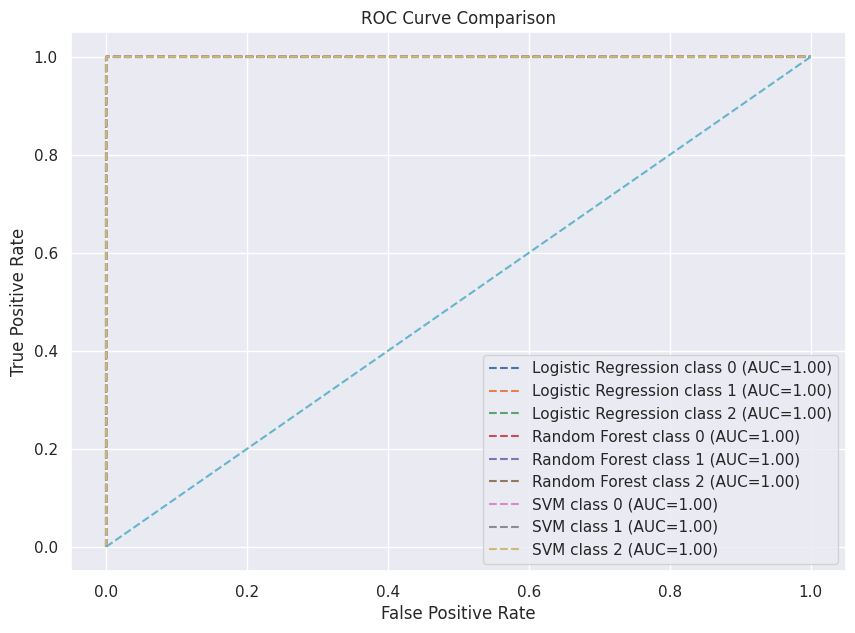


===== MODEL COMPARISON =====
Logistic Regression: 1.0000
Random Forest: 1.0000
SVM: 1.0000


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# =====================================
# CLEANING
# =====================================
df = df.drop_duplicates()
df = df.dropna(subset=['impact_tier'])

# Convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# =====================================
# FEATURE ENGINEERING
# =====================================
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.day_name()

df['has_negation'] = df['has_negation'].astype(int)

# Drop text-heavy columns (avoid leakage / noise)
df = df.drop(['title', 'description', 'url', 'matched_keywords', 'date'], axis=1)

# =====================================
# DEFINE FEATURES & TARGET
# =====================================
X = df.drop('impact_tier', axis=1)
y = df['impact_tier']

# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# =====================================
# TRAIN TEST SPLIT
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================
# AUTOMATIC COLUMN SELECTION
# =====================================
categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# =====================================
# PREPROCESSING PIPELINE (NO LEAKAGE)
# =====================================
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# =====================================
# MODELS
# =====================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True)
}

# =====================================
# TRAIN + EVALUATE
# =====================================
results = {}

plt.figure(figsize=(10,7))

for name, model in models.items():
    print(f"\n================ {name} ================\n")
    
    # Full pipeline (preprocessing + model)
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # =====================================
    # ROC CURVE
    # =====================================
    y_prob = pipeline.predict_proba(X_test)
    
    # Binary classification
    if len(np.unique(y_test)) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_prob[:,1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
    
    # Multi-class (One-vs-Rest)
    else:
        from sklearn.preprocessing import label_binarize
        
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        
        for i in range(y_test_bin.shape[1]):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, linestyle='--', label=f"{name} class {i} (AUC={roc_auc:.2f})")

# =====================================
# FINAL ROC PLOT
# =====================================
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =====================================
# FINAL MODEL COMPARISON
# =====================================
print("\n===== MODEL COMPARISON =====")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

## Thank you...pls upvote!!!!!!!!!!